In [14]:
%load_ext autoreload
%autoreload 2
%config InteractiveShell.ast_node_interactivity = 'none'
%config Completer.use_jedi = False

import sys, os
sys.path.insert(0, os.path.abspath('..'))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Importing Necessary packages along with OffRel Utilities

In [15]:
# Imports and style
import logging
logging.basicConfig(level=logging.INFO)
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import numpy as np
import matplotlib.pyplot as plt

import py_fatigue as pf
from OffRel.fatigue_load import WeibullFit, LongtermLoad
import pandas as pd

# Generating Random Time Series Signal

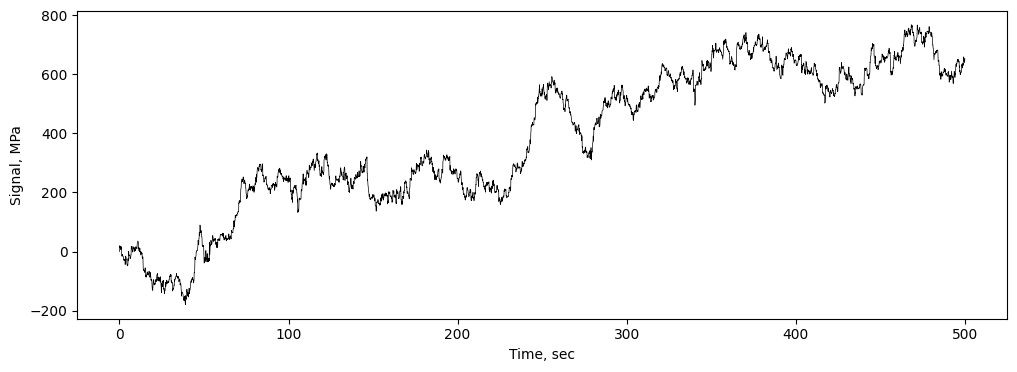

In [16]:
np.random.seed(42)

shape = 0.8      # Weibull shape parameter k
scale = 4.5      # Weibull scale parameter λ
n_cycles = 5000  # number of cycles
fs = 10          # sampling frequency in Hz
dt = 1 / fs      # time step in seconds

stress_ranges = np.random.weibull(shape, n_cycles) * scale

signal = [0.0]
for r in stress_ranges:
    direction = 1 if np.random.rand() > 0.5 else -1
    next_val = signal[-1] - direction * r
    signal.append(next_val)

signal = np.array(signal)
time = np.arange(len(signal)) * dt

plt.rcParams['figure.figsize'] = (12.0, 4.0)
plt.plot(time, signal, 'k', lw=0.5)
plt.xlabel("Time, sec")
plt.ylabel("Signal, MPa")
plt.show()

# Creating CycleCount instance and Rainflow Dictionaries to Test the Methods

In [17]:
# CycleCount definition
cycle_count = pf.CycleCount.from_timeseries(
    time=time, data=signal, range_bin_lower_bound=0.00005)

In [18]:
rf_data = cycle_count.as_dict()

In [19]:
df = pd.DataFrame({
    "time": time,
    "stress": signal
})

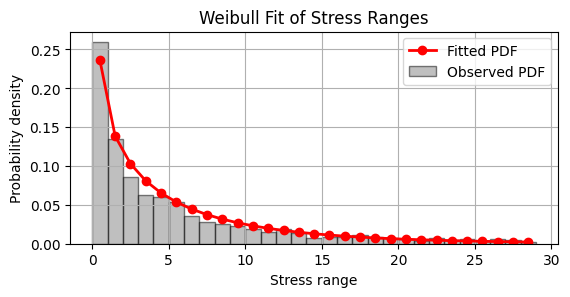

5.1531543755831555


In [20]:
print(WeibullFit.from_timeseries(df, k=0.8, scale_init=5,plot="both"))


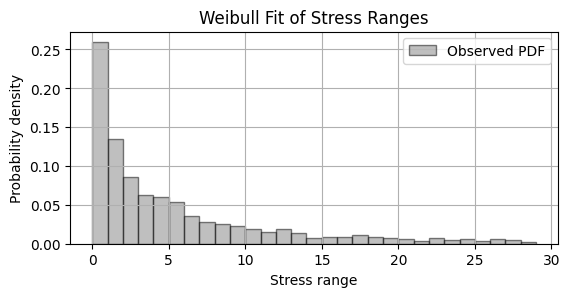

5.152928300191542


In [21]:
print(WeibullFit.from_rainflow(rf_data, k=0.8, scale_init=3, plot='observed'))

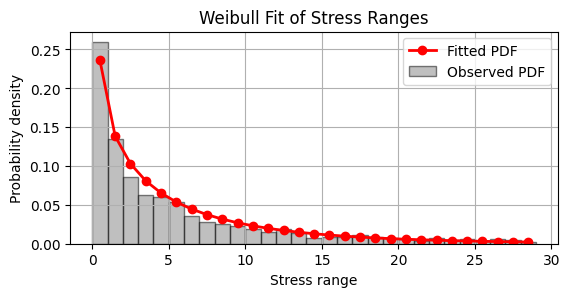

5.153919587620281


In [22]:
print(WeibullFit.from_cyclecount(cycle_count, k=0.8, scale_init=10, plot='both'))

# Defining SN Curve using py_fatigue

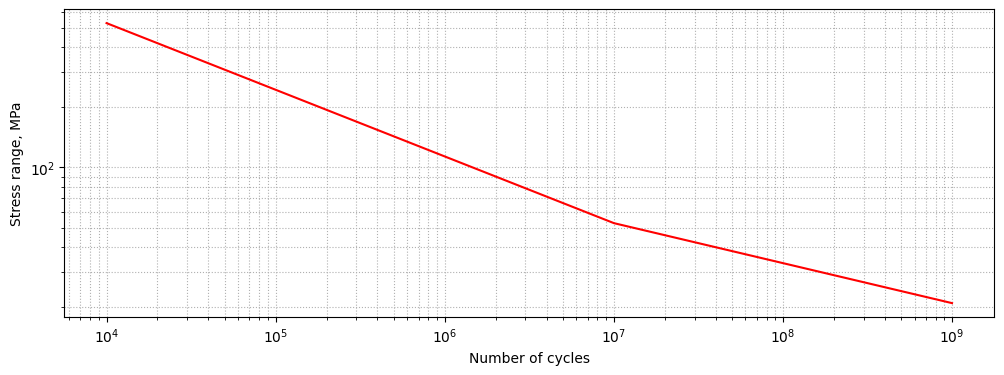

In [23]:

sn1 = pf.SNCurve(
    slope=[3, 5], 
    intercept=[12.164, 15.606],
    #N_knee=1e7,
    environment = 'Air', 
    curve = 'DNV-D-A',
    norm = 'DNVGL-RP-C203/2016',
    color='r'
)
sn1.plot()

# Solving for Weibull Scale Parameter using LongtermLoad.from_design_to_the_limit

In [24]:
config = {                                                                                                                                                                                                
      "sn": sn1,
      "t_years": 20,                                                                                                                                                                                                                   
      "fdf": 3,
      "mean_period": 6.25,  
  }
ltl = LongtermLoad(**config)
print("Weibull scale parameter (q):", ltl.from_design_to_the_limit())


Weibull scale parameter (q): 7.506534162478013


# Calculating Fatigue Damage using LongtermLoad

In [25]:

n_cycles = ltl.t_years * 3600 * 24 * 365 / ltl.mean_period
print(ltl.fatigue_damage_weibull(n_cycles=n_cycles, q=7.5066, h=0.8))

0.33334421038133133
